In [4]:
import cv2  # openvc-python is where the librayry with the homography transform code
import numpy as np
import matplotlib.pyplot as plt

# load in any image of your choice

In [14]:
# Load image
img = cv2.imread("/Users/brynlloyd/Downloads/IMG_6096.jpeg")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

h, w = img.shape[:2]

# the transformation is defined here
*you can change these points to be anything you like*

- src_pts is a list of (at least) 4 points in the original image

- dst_pts is a list of points in the warped image (there must be the same number of points as src_pts)

- currently takes an arbitrary quadrilateral in the image, and warps so that this reference shape becomes a rectangle

In [61]:

src_pts = np.array([
    [700, 100],   # top-left
    [2530, 1350],   # top-right
    [2700, 2600],   # bottom-right
    [400, 2700],   # bottom-left
], dtype=np.float32)

# Destination points (in warped image)
dst_pts = np.array([
    [700, 100],   # top-left
    [4000, 100],   # top-right
    [4000, 2700],   # bottom-right
    [700, 2700],   # bottom-left
], dtype=np.float32)

# compute Homography and apply to image

In [62]:
# Compute homography
H = cv2.getPerspectiveTransform(src_pts, dst_pts)

# Warp
warped = cv2.warpPerspective(
    img,
    H,
    (w, h),
    flags=cv2.INTER_LINEAR
)

# plotting

- plots original and warped image, with the source and destination points plotted on the relevant image

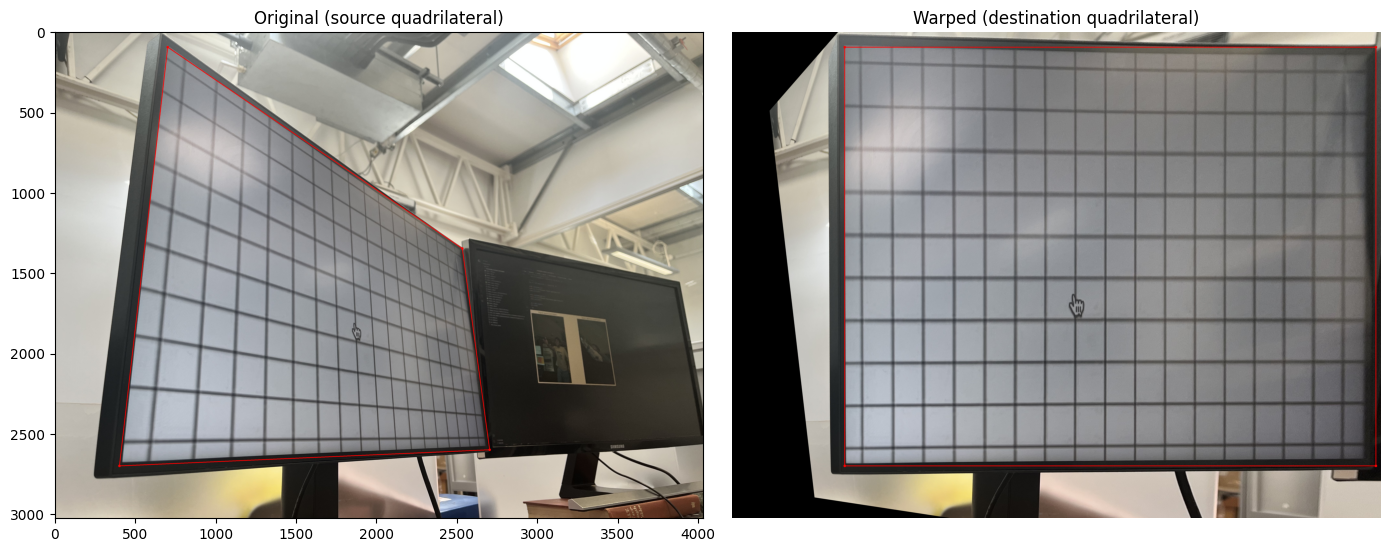

In [63]:


# Draw source quadrilateral
img_vis = img.copy()
cv2.polylines(
    img_vis,
    [src_pts.astype(np.int32)],
    isClosed=True,
    color=(255, 0, 0),
    thickness=4,
)

for p in src_pts.astype(np.int32):
    cv2.circle(img_vis, tuple(p), 8, (255, 0, 0), -1)

# Draw destination quadrilateral
warped_vis = warped.copy()
cv2.polylines(
    warped_vis,
    [dst_pts.astype(np.int32)],
    isClosed=True,
    color=(255, 0, 0),
    thickness=4,
)

for p in dst_pts.astype(np.int32):
    cv2.circle(warped_vis, tuple(p), 8, (255, 0, 0), -1)

# Display
fig, ax = plt.subplots(1, 2, figsize=(14, 7))

ax[0].imshow(img_vis)
ax[0].set_title("Original (source quadrilateral)")
# ax[0].axis("off")

ax[1].imshow(warped_vis)
ax[1].set_title("Warped (destination quadrilateral)")
ax[1].axis("off")

plt.tight_layout()
plt.show()